# T32 — Dynamic topography through the reference frames: mantle → plate → difference


**Cluster E: Mantle dynamics + dynamic topography.**
Geodynamic models output **dynamic topography (DT)** in a **mantle (absolute) reference frame**: DT as a function of a fixed position in the mantle. But the question we usually care about — *how much did mantle flow raise or lower a particular piece of continental crust between two times?* — cannot be answered in the mantle frame, because the plate **slides over the mantle**. Differencing two mantle-frame grids at the same geographic cell compares *different crustal columns*.

This notebook walks through the fix, with a map at every stage:

1. **Mantle reference frame** — load and map a raw DT grid.
2. **Plate reference frame** — rotate each plate's DT from its position at time *t* back to its present-day position (the step that makes crustal columns comparable), and map it.
3. **Difference maps** — subtract two plate-frame grids to get the DT change each crustal column experienced, and map it on the paleogeography.

Data: **Young et al. (2022) `gld428`** mantle-reference-frame grids + the M21 NNR (Merdith 2021, no-net-rotation) plate model, all in `data/Young2022_dynamic_topo/`. We use the **5-Myr set (0–250 Ma)** here and invite you to extend to the **20-Myr set (0–960 Ma)** at the end.

> Companion notebooks: **T31** consumes *already*-plate-frame grids; **T44** is the terse version of this rotation. **T32** is the fully explained walk-through.


## 0. Configuration + data discovery
The data folder holds rotations (`.rot`), static polygons and topologies (`.gpml`/`.gpmlz`), and the DT grids (`.nc`). Because exact filenames vary, this cell **auto-discovers** them and prints what it found — check the printout on first run.

In [ ]:
import os as _os
import os
from pathlib import Path
# hop up to the tutorials root so zenodo_data/ resolves whether launched from Notebooks/ or root
for _up in ('.', '..', '../..'):
    if (Path(_up)/'zenodo_data').exists():
        _os.chdir(_up); break

import re
from glob import glob
import numpy as np, xarray as xr

DATA_DIR   = os.environ.get("ZENODO_YOUNG2022_DIR", "zenodo_data/dynamic_topography_Young2022")
ANCHOR_PLATE_ID = 0
MODEL_LABEL = 'Young 2022 gld428 · M21 NNR'
STEP_MYR_5  = 20      # differencing interval for the 5-Myr set demo (multiple of 5)
assert Path(DATA_DIR).exists(), f'set DATA_DIR — not found: {DATA_DIR}'

# --- discover model files -------------------------------------------------
rot_files = sorted(glob(f'{DATA_DIR}/**/*.rot', recursive=True))
gpml_all  = sorted(glob(f'{DATA_DIR}/**/*.gpml', recursive=True) +
                   glob(f'{DATA_DIR}/**/*.gpmlz', recursive=True))
# static polygons = the partition polygons Raster.reconstruct needs
stat_hits = [f for f in gpml_all if re.search(r'static|polygon|continent', os.path.basename(f), re.I)]
static_polygons_file = stat_hits[0] if stat_hits else (gpml_all[0] if gpml_all else None)
# topologies (for boundary overlays) = the other gpml, if any
topo_files = [f for f in gpml_all if f != static_polygons_file
              and not re.search(r'craton', os.path.basename(f), re.I)]

# --- discover grids: map integer age -> path, split by cadence -------------
nc_files = sorted(glob(f'{DATA_DIR}/**/*.nc', recursive=True))
def _age_of(fp):
    m = re.findall(r'(\d+)', os.path.basename(fp))
    return int(m[-1]) if m else None
age_map = {}
for fp in nc_files:
    a = _age_of(fp)
    if a is not None:
        age_map.setdefault(a, fp)
ages = np.array(sorted(age_map))
set5  = ages[(ages <= 250) & (ages % 5 == 0)]                 # 5-Myr set (demo)
set20 = ages[(ages % 20 == 0)]                                # 20-Myr set (extension)
print(f'rotations: {len(rot_files)} file(s)')
print(f'static polygons: {static_polygons_file}')
print(f'topologies: {len(topo_files)} file(s)')
print(f'grids: {len(age_map)} ages  ·  5-Myr set 0-250: {list(set5)}')
print(f'                            20-Myr set: {list(set20)}')


## 1. Load the plate model + a grid-reading helper
`gplately.Raster.reconstruct` uses the **static polygons** to cookie-cut a global grid into per-plate blocks and rotate each with the rotation model. Topologies are only for drawing plate boundaries.

In [2]:
import gplately, pygmt, pygplates
from IPython.display import display, HTML
print(f'gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}')

rotation_model    = pygplates.RotationModel(rot_files)
static_polys_fc   = pygplates.FeatureCollection(static_polygons_file)
topology_features = [pygplates.FeatureCollection(f) for f in topo_files] or None
recon = gplately.PlateReconstruction(rotation_model=rotation_model,
                                     topology_features=topology_features,
                                     static_polygons=static_polys_fc,
                                     anchor_plate_id=ANCHOR_PLATE_ID)
print('plate model loaded  ·  anchor', ANCHOR_PLATE_ID)

def load_grid(age_ma):
    """Load the mantle-frame DT grid at age_ma; normalise lat ascending, lon [-180,180]."""
    ds = xr.open_dataset(age_map[int(age_ma)])
    var = 'z' if 'z' in ds.data_vars else list(ds.data_vars)[0]
    da = ds[var]
    latn = [d for d in da.dims if 'lat' in d.lower()][0]
    lonn = [d for d in da.dims if 'lon' in d.lower()][0]
    da = da.rename({latn: 'lat', lonn: 'lon'})
    if da['lat'].values[0] > da['lat'].values[-1]:
        da = da.isel(lat=slice(None, None, -1))
    if float(da['lon'].max()) > 180:
        da = da.assign_coords(lon=(((da['lon'] + 180) % 360) - 180)).sortby('lon')
    return da


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0
plate model loaded  ·  anchor 0


## 2. A small mapping helper
One function to paint any global grid on a Mollweide world, optionally overlaying reconstructed continents/plate boundaries at a chosen age.

In [ ]:
PROJECTION = 'W0/22c'; REGION = 'd'

def map_grid(da, title, series, cmap='roma', overlay_age=None, label='m'):
    da = da.copy(); da.gmt.registration = 0; da.gmt.gtype = 1
    fig = pygmt.Figure()
    fig.basemap(region=REGION, projection=PROJECTION, frame=['af'])
    pygmt.makecpt(cmap=cmap, series=list(series), continuous=True, background='o')
    fig.grdimage(grid=da, cmap=True, nan_transparent=True)
    if overlay_age is not None:
        gplot = gplately.PlotTopologies(plate_reconstruction=recon, coastlines=None,
                                        continents=static_polys_fc, COBs=None,
                                        time=float(overlay_age), plot_engine=gplately.PygmtPlotEngine())
        for fn in (lambda: fig.plot(data=gplot.get_continents(), pen='0.35p,gray30'),
                   lambda: gplot.plot_all_topological_sections(fig, pen='0.4p,gray40'),
                   lambda: gplot.plot_subduction_teeth(fig, color='black')):
            try: fn()
            except Exception: pass
    fig.colorbar(frame=f'+l{label}', position='JBC+w14c/0.35c+h+o0/1.4c')
    fig.text(text=title, position='TL', offset='0.25c/-0.25c', justify='TL',
             font='13p,Helvetica-Bold,black', fill='white', pen='0.6p,gray40')
    fig.show(width=1050); display(HTML('<div style="height:0.6cm"></div>'))
    return fig


## 3. Step 1 — the **mantle reference frame**

Here is the raw DT grid at 100 Ma as the model produced it: dynamic topography as a function of **absolute mantle position**. Red is dynamic uplift (mantle upwelling support), blue is dynamic subsidence (downwelling). Note the continents drawn here are at their *100 Ma paleo-positions* — but the DT field itself is anchored to the mantle, not the plates.

100 Ma mantle-frame DT range: [-7062, +2345] m


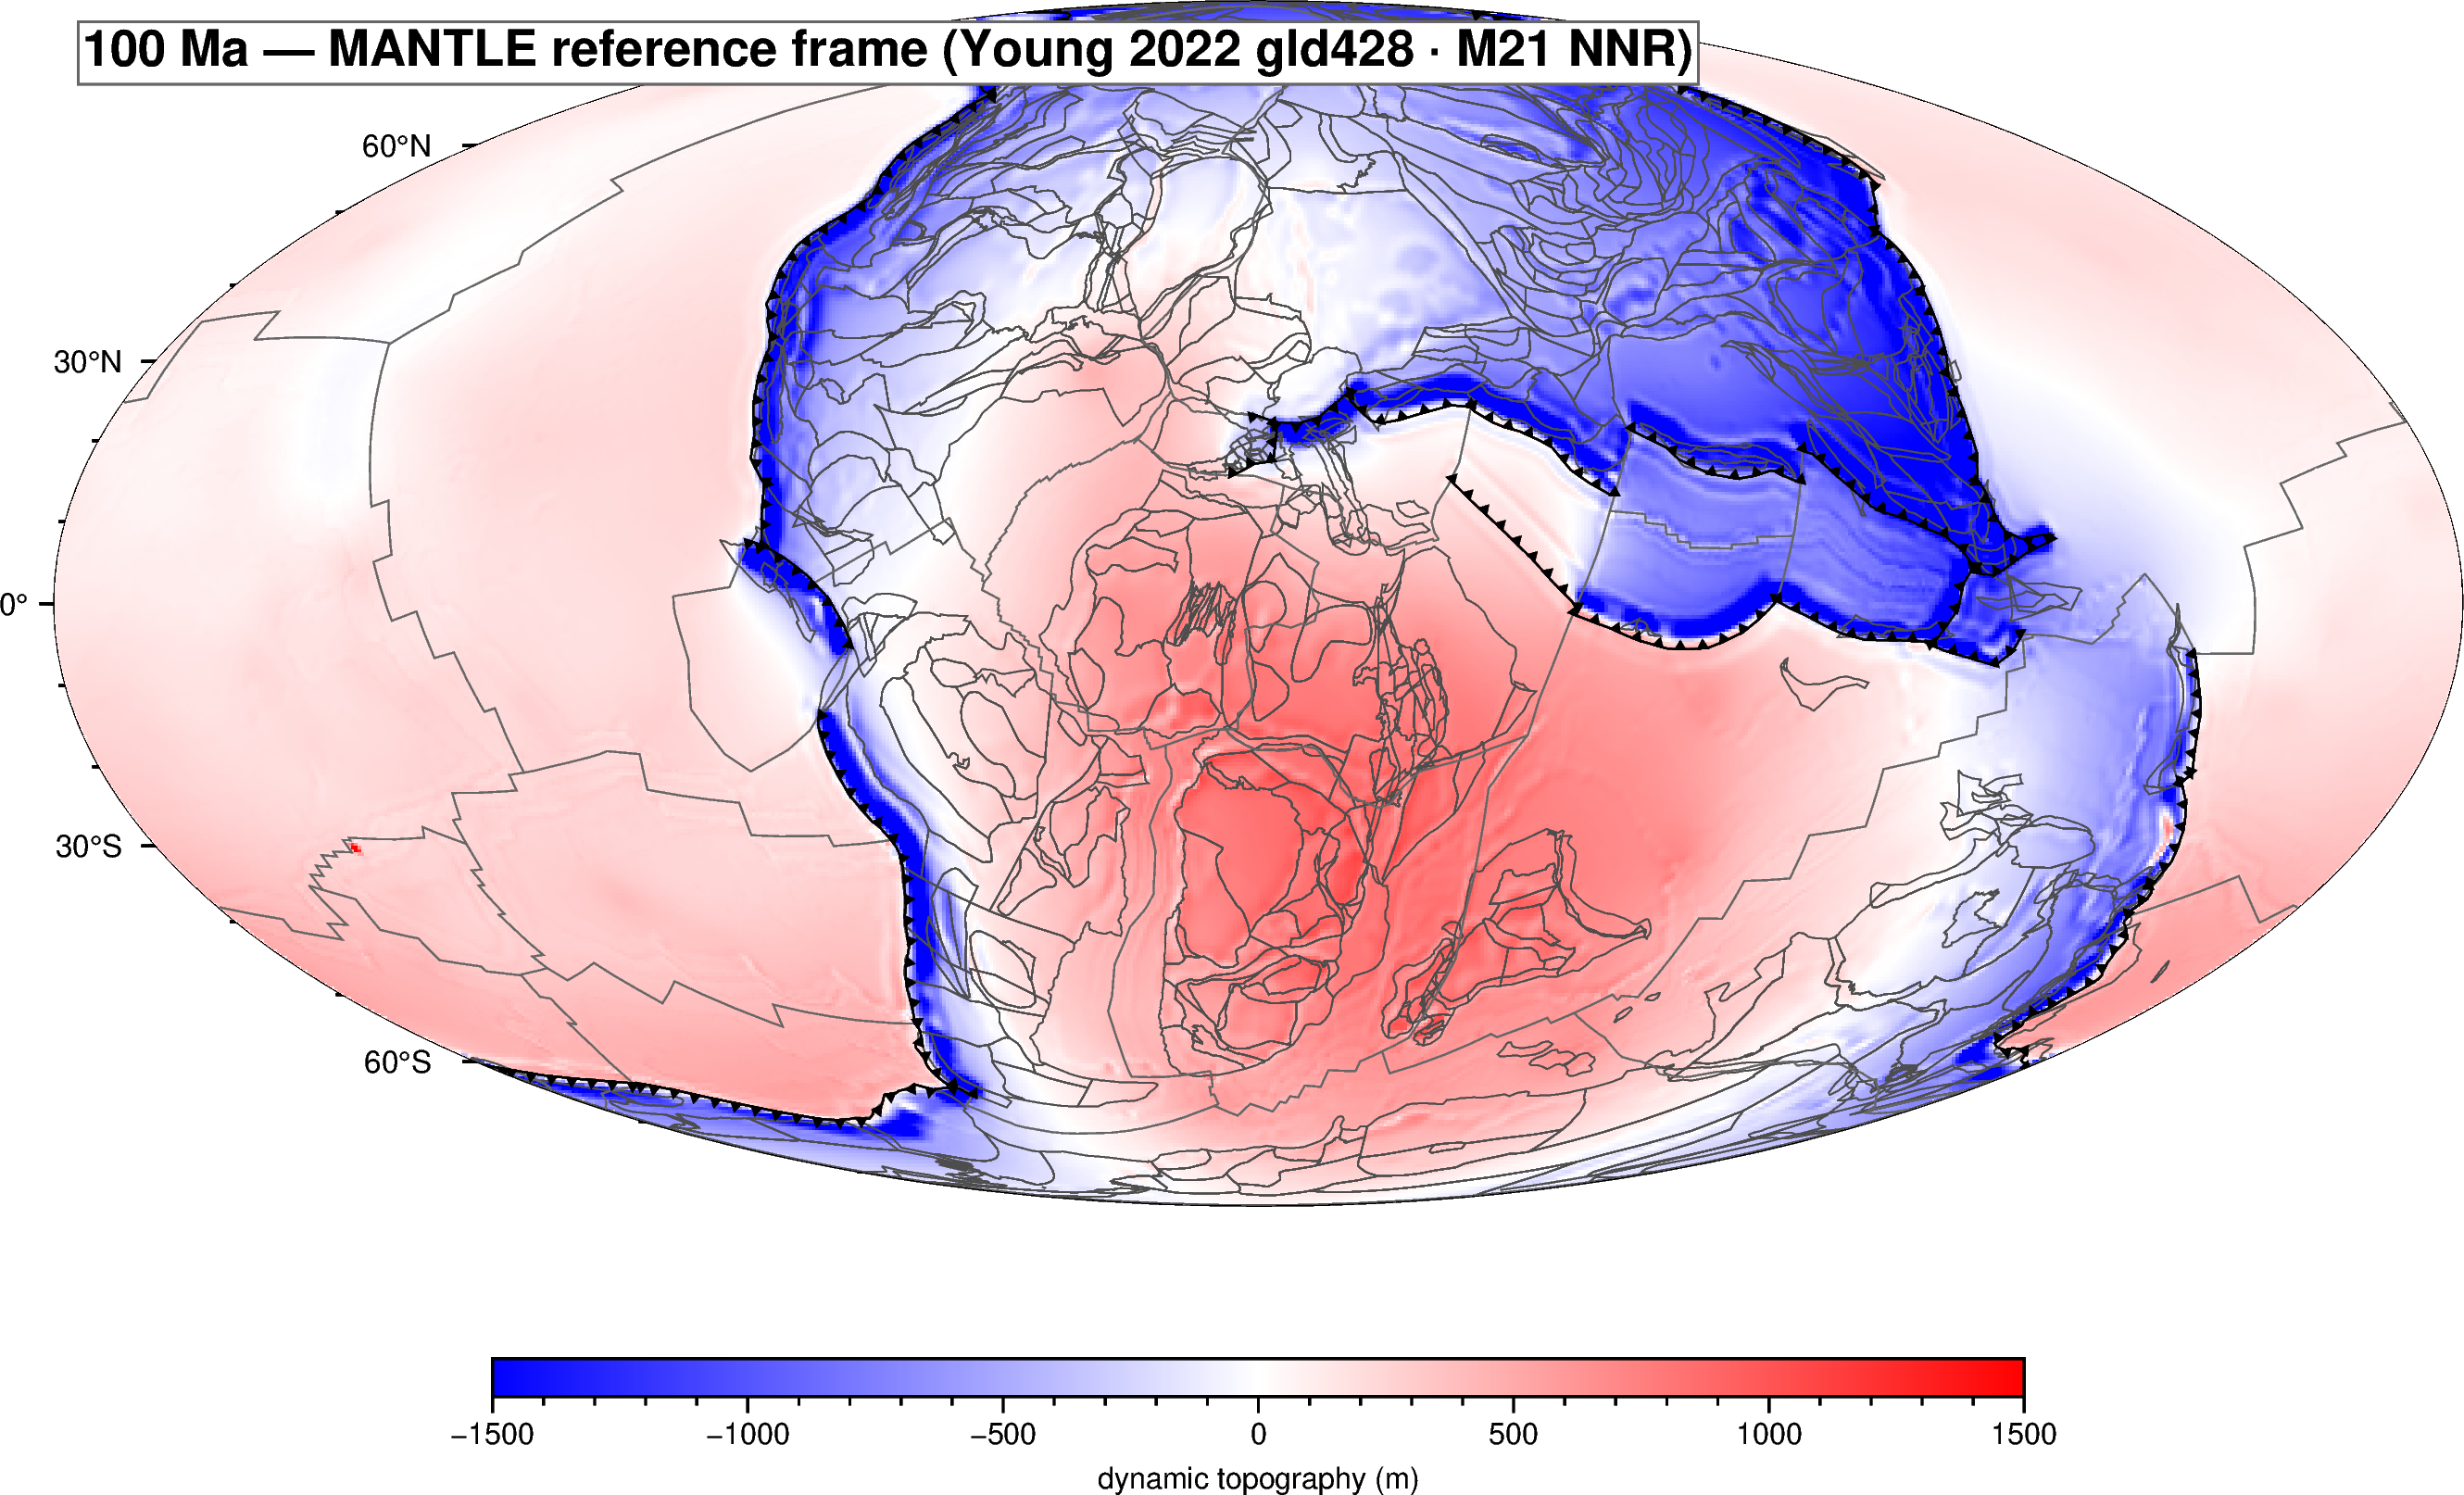

In [4]:
DEMO_AGE = 100
g_mantle = load_grid(DEMO_AGE)
print(f'{DEMO_AGE} Ma mantle-frame DT range: [{float(g_mantle.min()):+.0f}, {float(g_mantle.max()):+.0f}] m')
map_grid(g_mantle, f'{DEMO_AGE} Ma — MANTLE reference frame ({MODEL_LABEL})',
         series=(-1500, 1500, 100), overlay_age=DEMO_AGE, label='dynamic topography (m)');


## 4. Step 2 — rotate into the **plate reference frame**

We declare a `gplately.Raster` **valid at `time=t`** (its positions are mantle positions at *t*) and reconstruct it to **`time=0`**. gplately cookie-cuts the grid by the static polygons and reverse-rotates each plate from its *t* position to its **present-day** position. The result is DT indexed by **present-day crustal position** — so a given continental column always maps to the same cell, regardless of age. Mapped below with present-day continents.

100 Ma plate-frame DT (present-day positions): [-7062, +1103] m


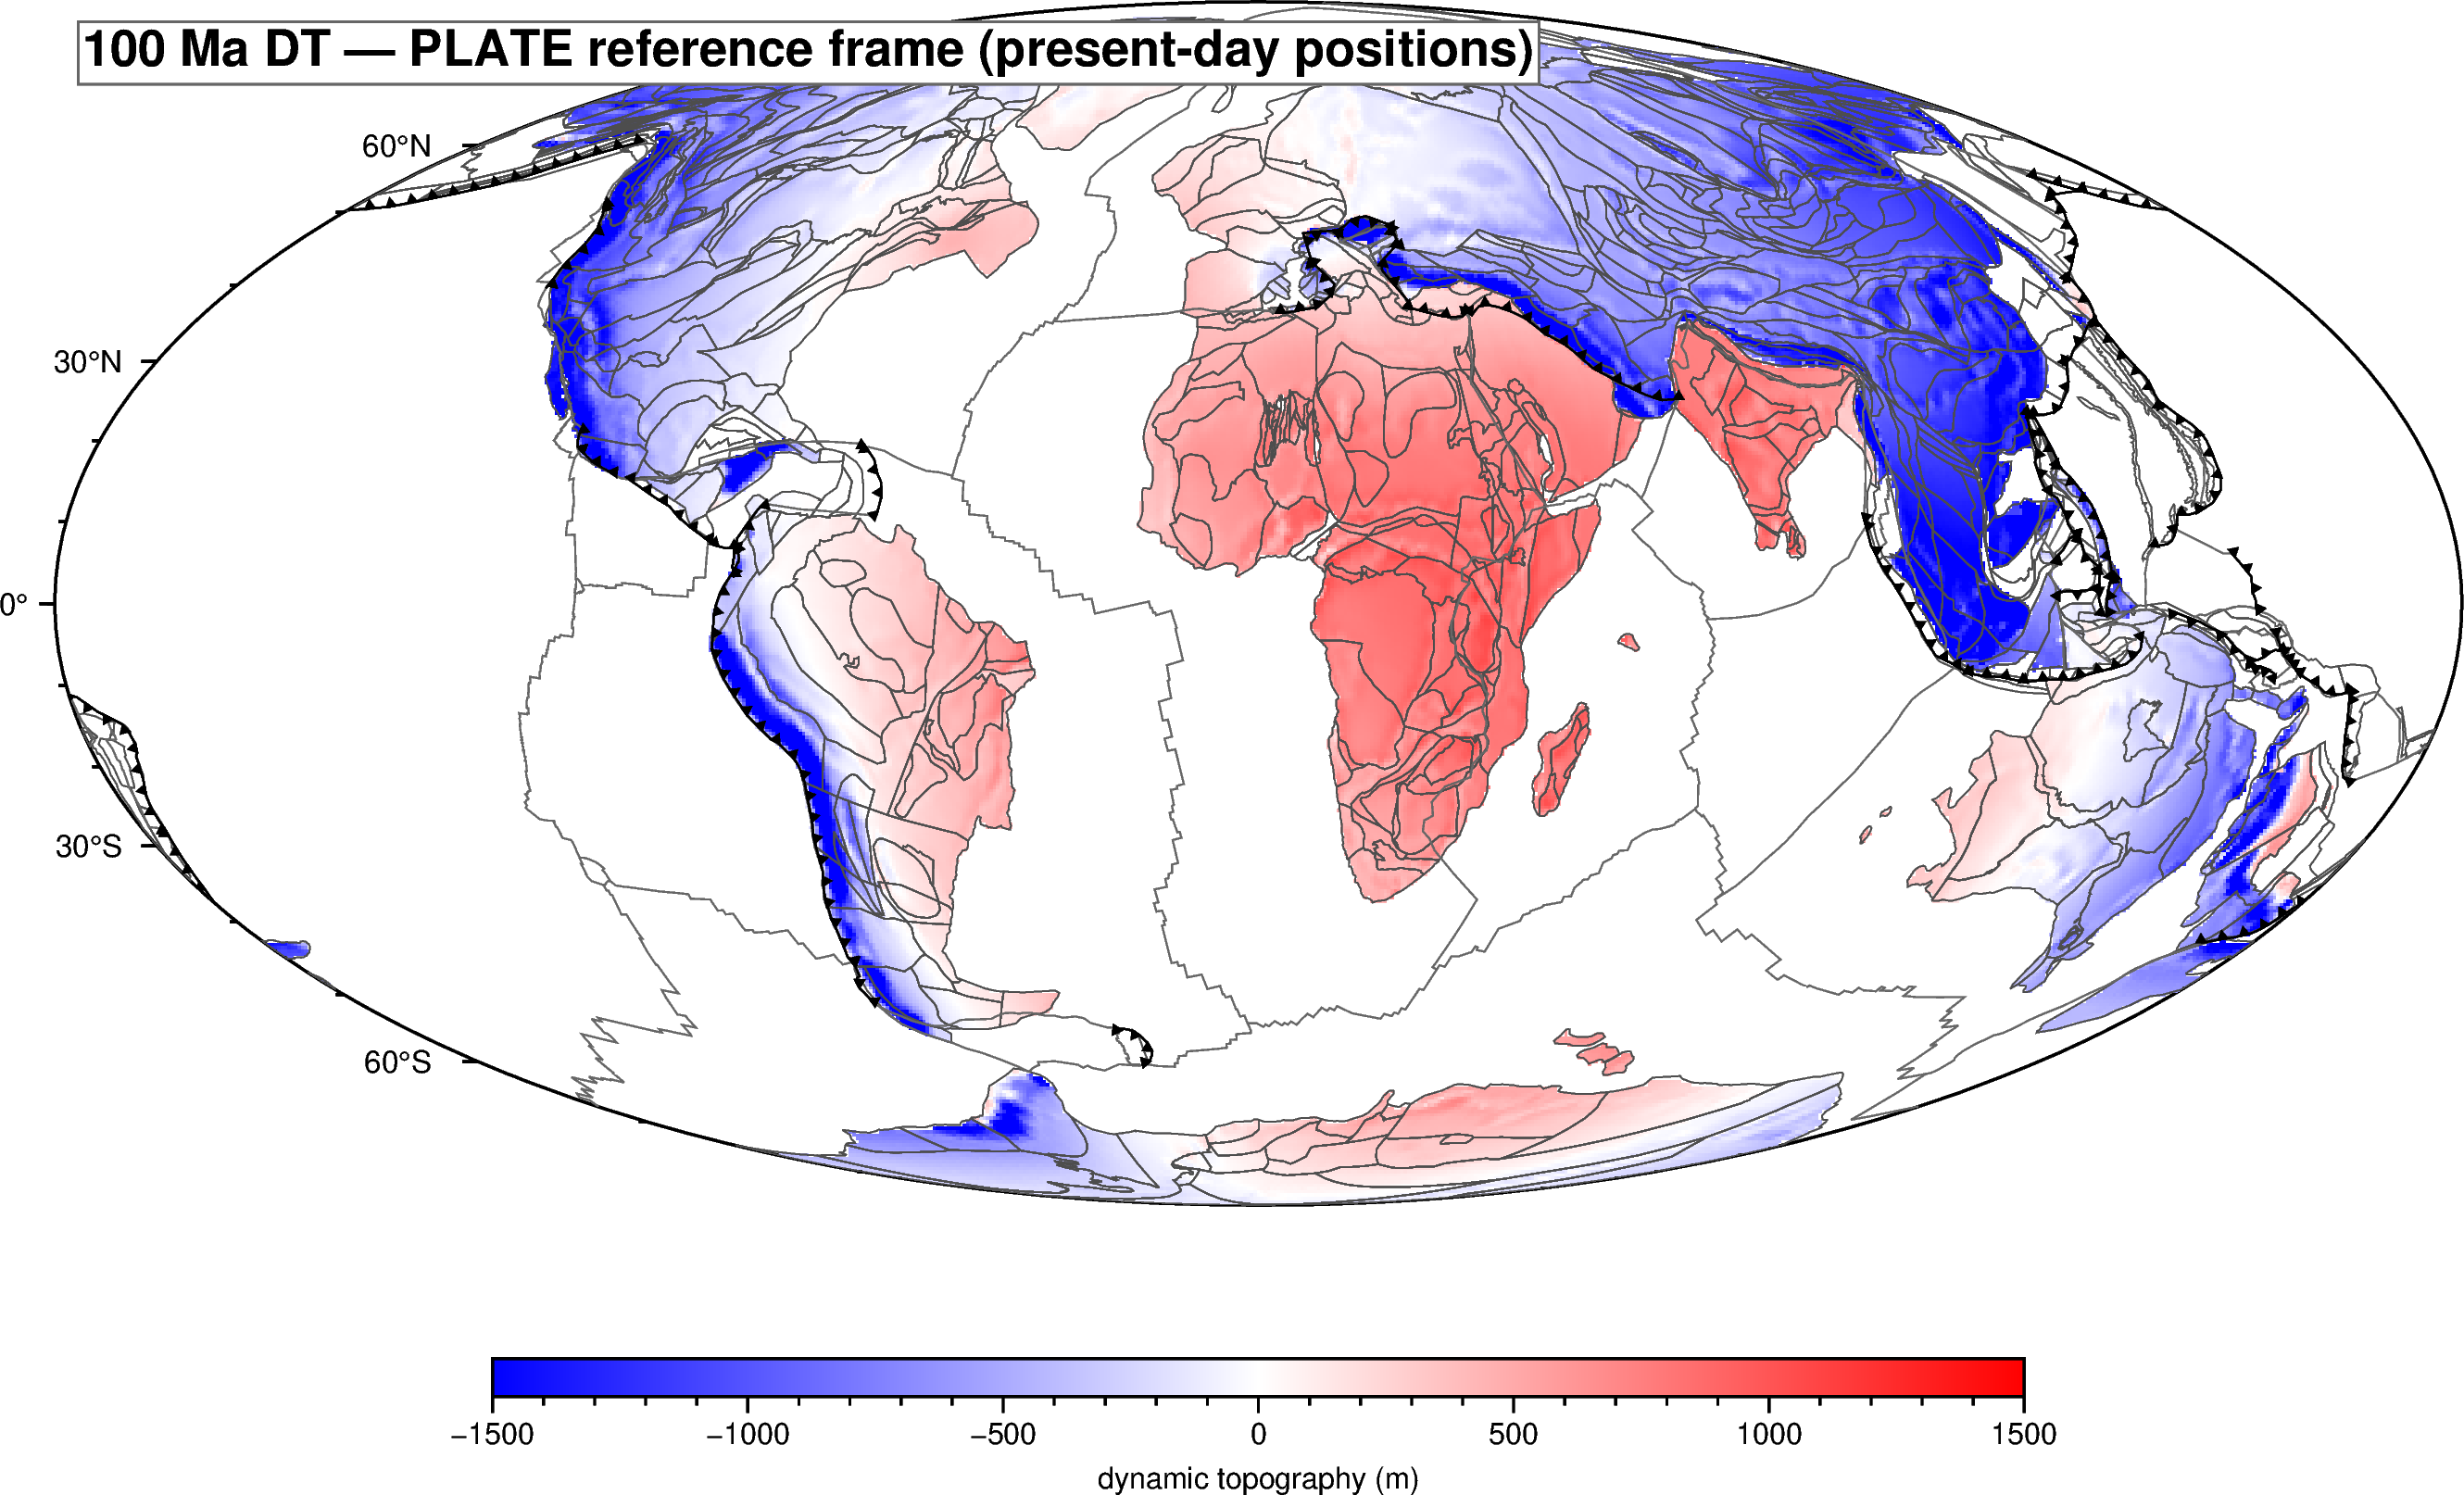

In [5]:
def to_plate_frame(da_mantle, age_ma):
    """Rotate a mantle-frame grid (valid at age_ma) into the present-day plate frame."""
    lat = da_mantle['lat'].values; lon = da_mantle['lon'].values
    r = gplately.Raster(data=da_mantle.values.astype(np.float32), plate_reconstruction=recon,
                        time=float(age_ma),
                        extent=[float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())])
    rec = r.reconstruct(time=0.0, anchor_plate_id=ANCHOR_PLATE_ID, threads=1, inplace=False)
    arr = np.asarray(rec.data if rec is not None else r.data)
    return xr.DataArray(arr, dims=('lat','lon'), coords={'lat': lat, 'lon': lon}, name='z')

g_plate = to_plate_frame(g_mantle, DEMO_AGE)
print(f'{DEMO_AGE} Ma plate-frame DT (present-day positions): '
      f'[{float(np.nanmin(g_plate.values)):+.0f}, {float(np.nanmax(g_plate.values)):+.0f}] m')
map_grid(g_plate, f'{DEMO_AGE} Ma DT — PLATE reference frame (present-day positions)',
         series=(-1500, 1500, 100), overlay_age=0, label='dynamic topography (m)');


## 5. Step 3 — **difference** two plate-frame grids

Now the payoff. Rotate both *t* and *t + Δ* into the plate frame and subtract:

> Δz(t) = DT_plateframe(t) − DT_plateframe(t + Δ)

Because both are indexed by present-day crustal position, Δz is the DT change **each crustal column** actually experienced over the interval. We map it rotated back onto the paleogeography at *t* (m/Myr): red = mantle flow lifting the surface over the interval, blue = pulling it down.

Δz over 20 Myr ending at 100 Ma: [-280.2, +247.0] m/Myr


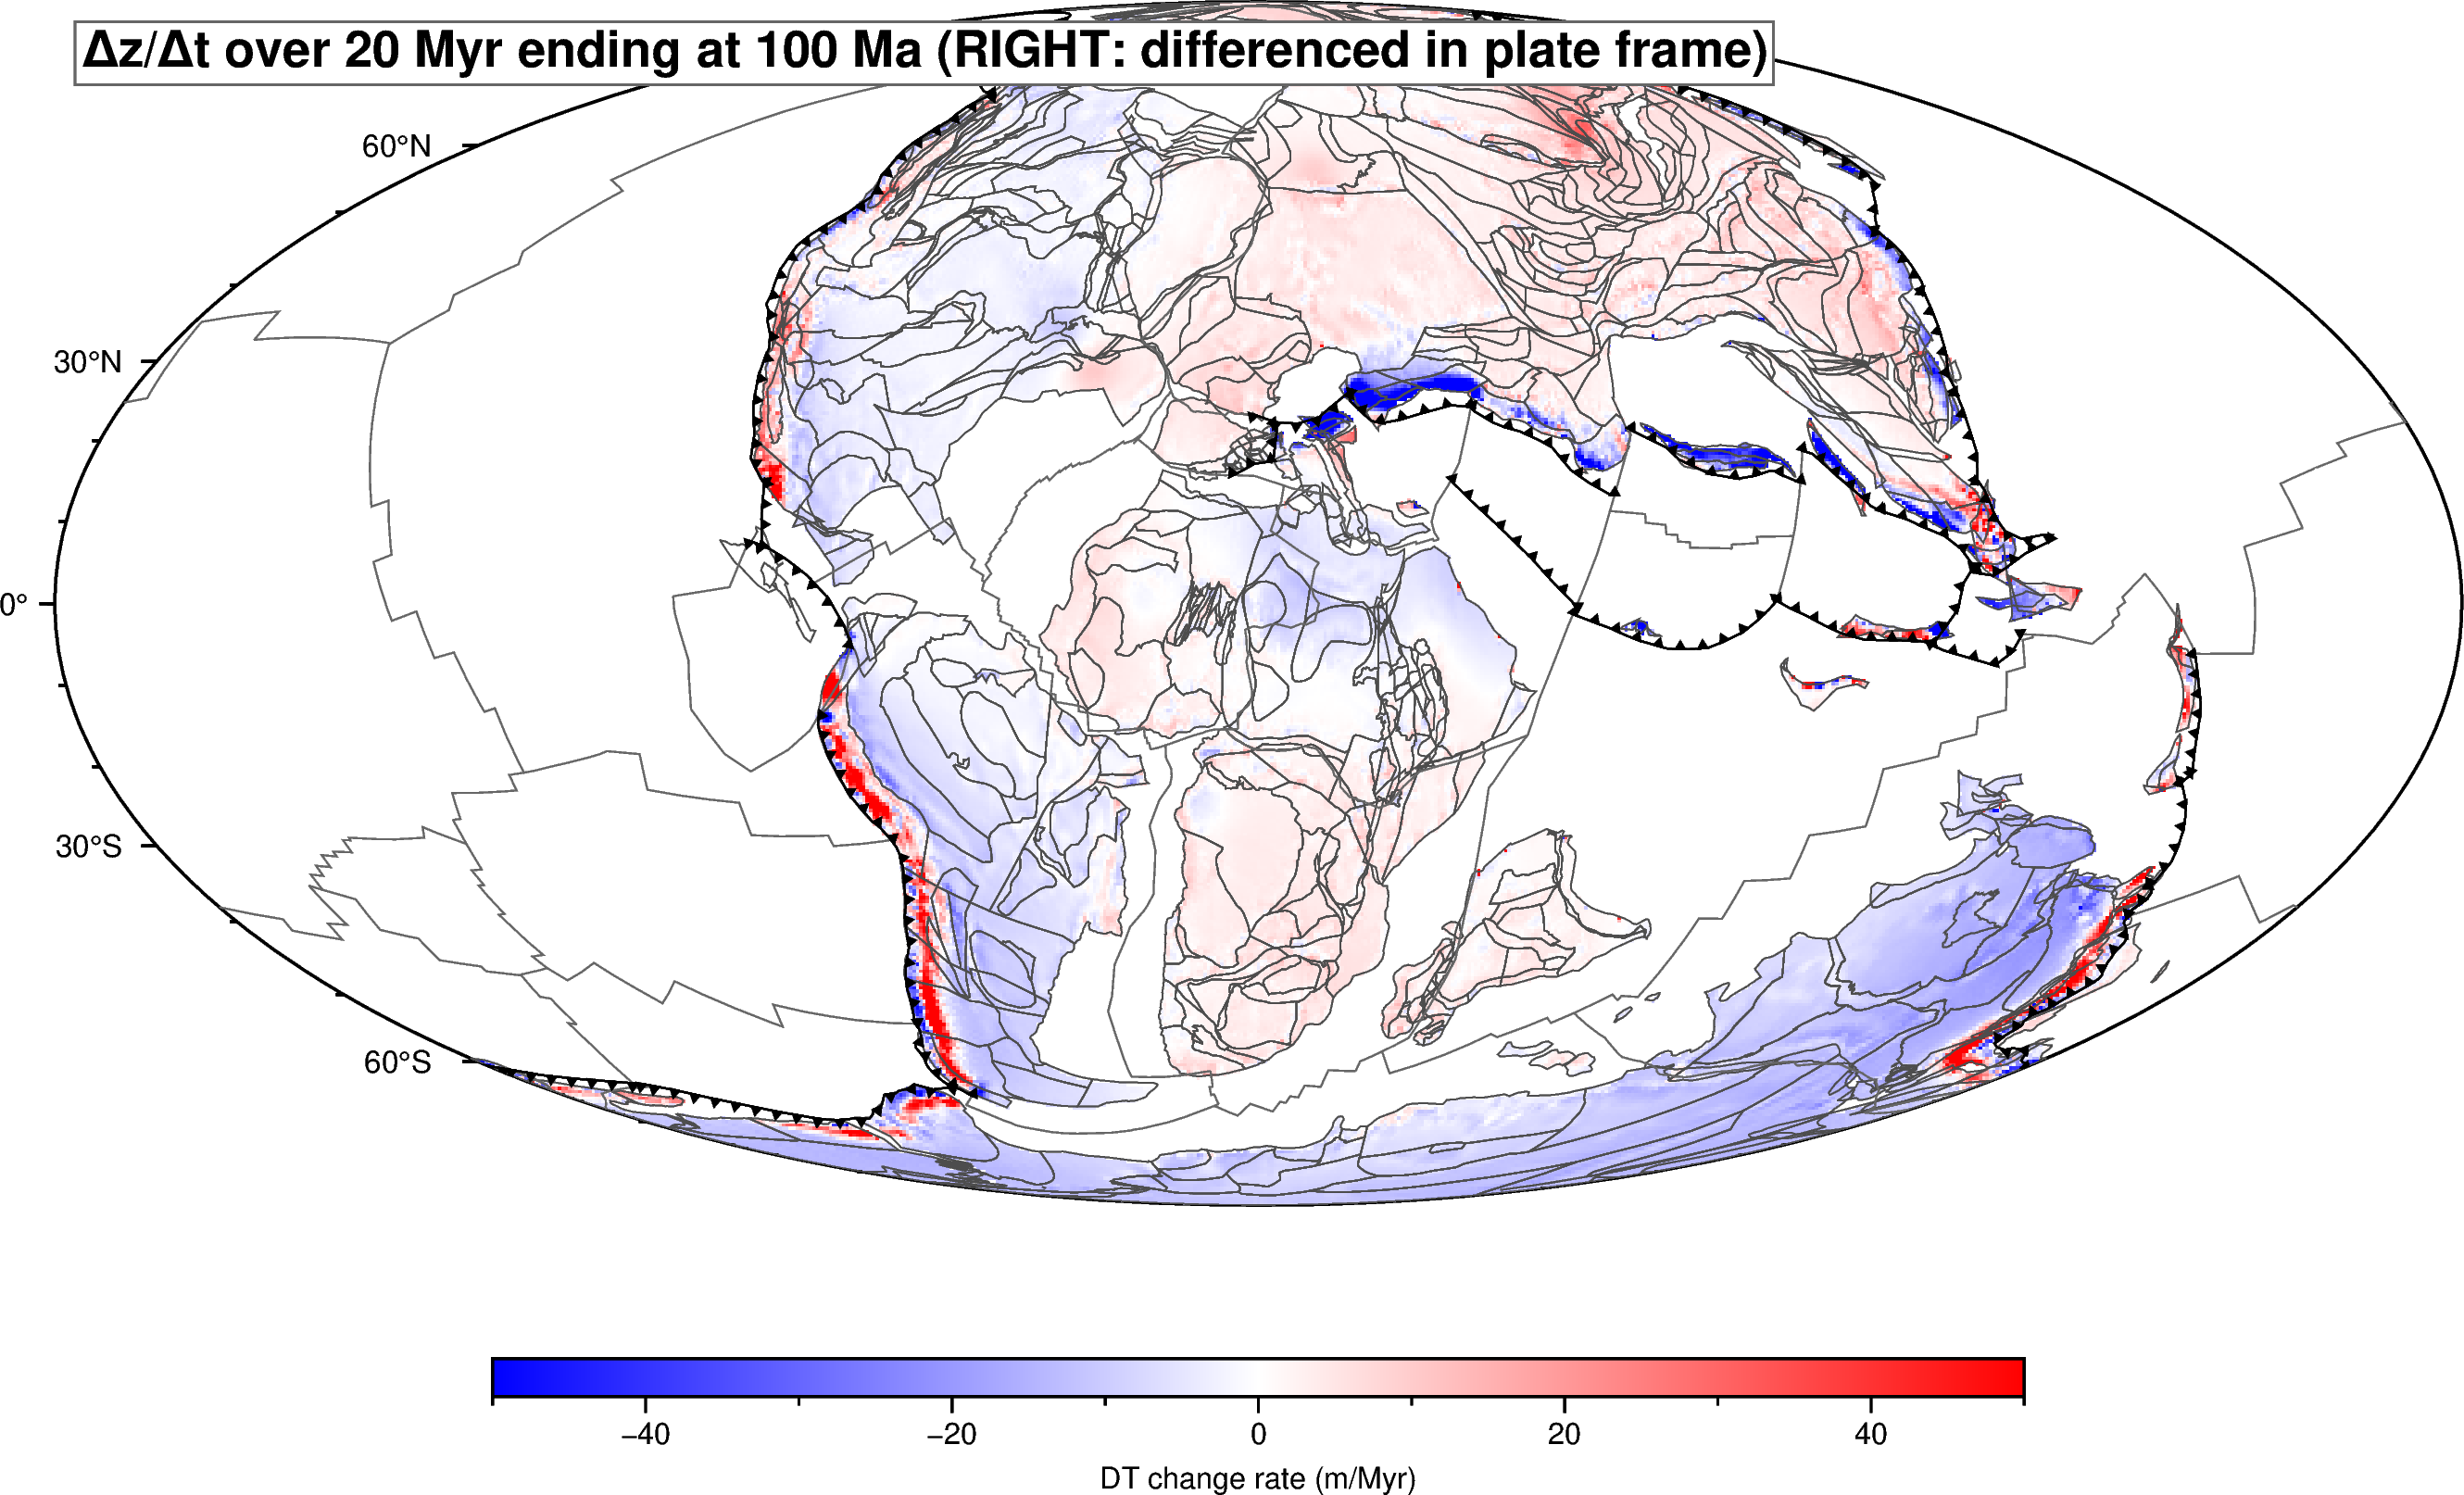

In [6]:
def to_paleo(da_plate, age_ma):
    """Push a present-day plate-frame grid out to its paleo-position at age_ma (for display)."""
    lat = da_plate['lat'].values; lon = da_plate['lon'].values
    r = gplately.Raster(data=da_plate.values.astype(np.float32), plate_reconstruction=recon, time=0,
                        extent=[float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())])
    rec = r.reconstruct(time=float(age_ma), anchor_plate_id=ANCHOR_PLATE_ID, threads=1, inplace=False)
    arr = np.asarray(rec.data if rec is not None else r.data)
    return xr.DataArray(arr, dims=('lat','lon'), coords={'lat': lat, 'lon': lon}, name='z')

def plate_frame_dz(age_ma, step_myr):
    pf_t   = to_plate_frame(load_grid(age_ma), age_ma)
    pf_tdt = to_plate_frame(load_grid(age_ma + step_myr), age_ma + step_myr)
    dz = pf_t - pf_tdt; dz.name = 'z'; return dz

dz_plate = plate_frame_dz(DEMO_AGE, STEP_MYR_5)
dz_paleo = to_paleo(dz_plate, DEMO_AGE) / float(STEP_MYR_5)      # m/Myr on paleogeography
print(f'Δz over {STEP_MYR_5} Myr ending at {DEMO_AGE} Ma: '
      f'[{float(np.nanmin(dz_paleo.values)):+.1f}, {float(np.nanmax(dz_paleo.values)):+.1f}] m/Myr')
map_grid(dz_paleo, f'Δz/Δt over {STEP_MYR_5} Myr ending at {DEMO_AGE} Ma (RIGHT: differenced in plate frame)',
         series=(-50, 50, 2), overlay_age=DEMO_AGE, label='DT change rate (m/Myr)');


## 6. A time series with the 5-Myr set (0–250 Ma)
The 5-Myr cadence lets you pick a short Δ. Here are four snapshots; change `SNAPSHOTS`/`STEP_MYR_5` freely.

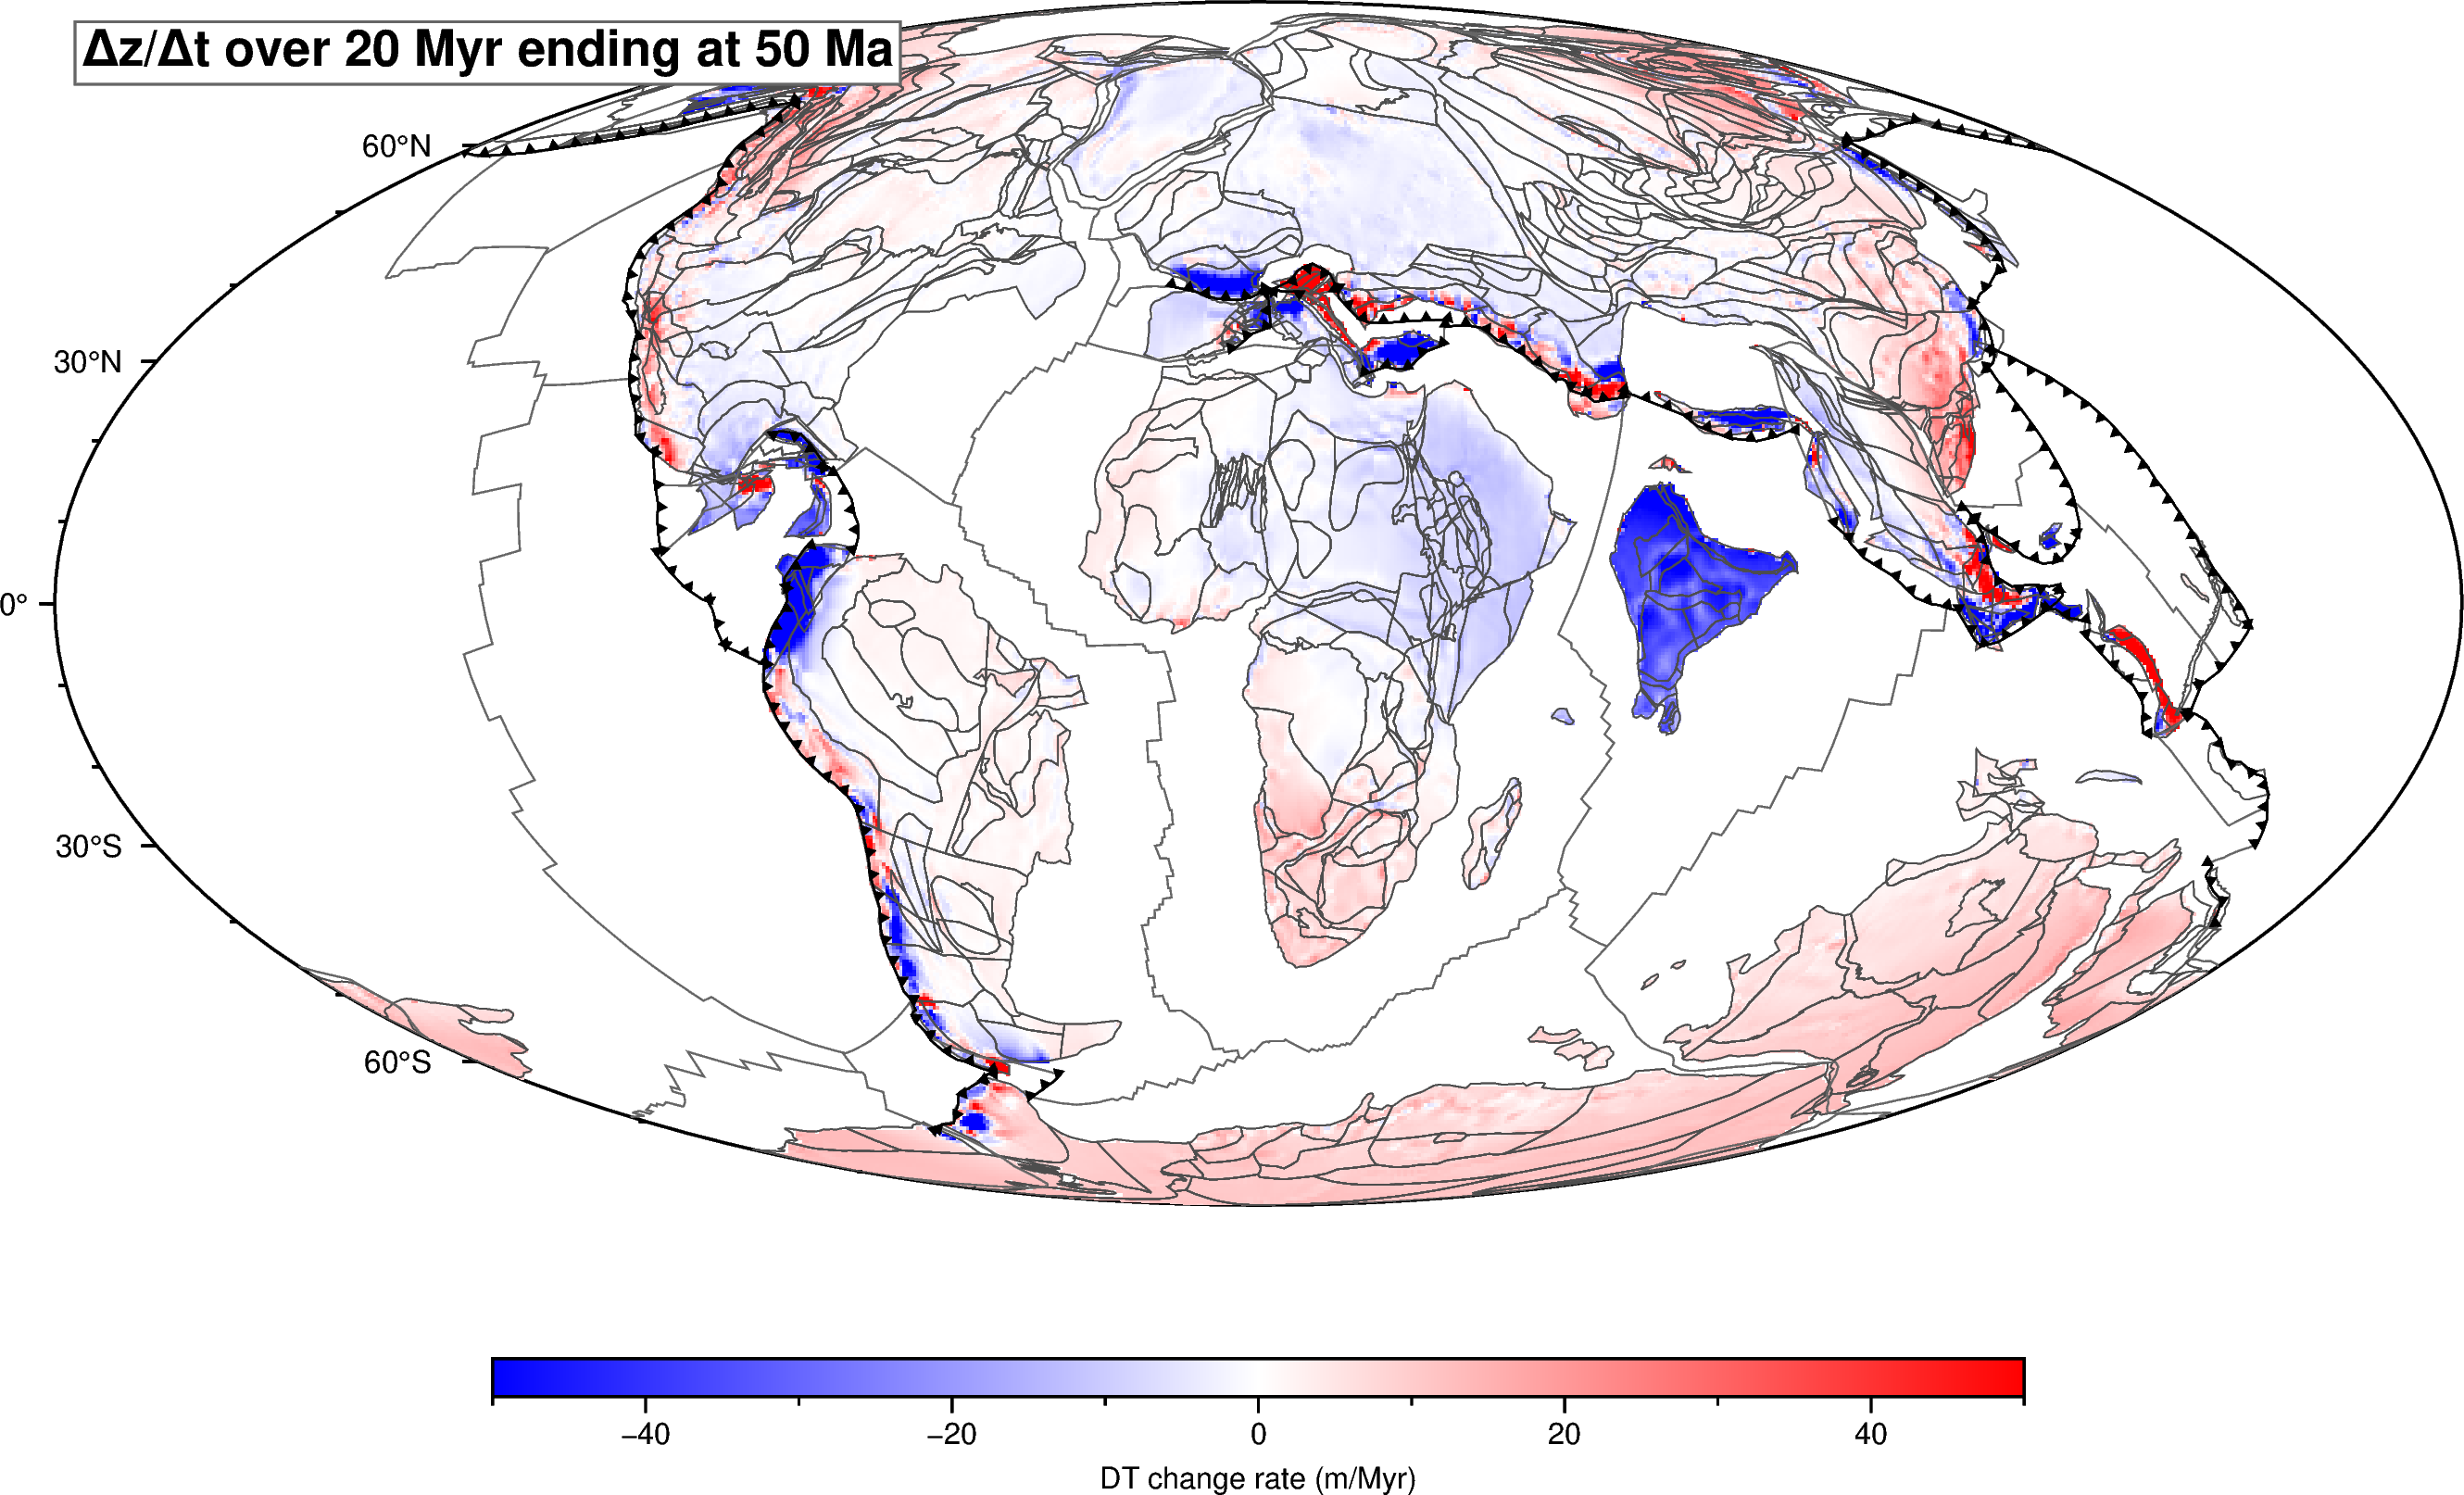

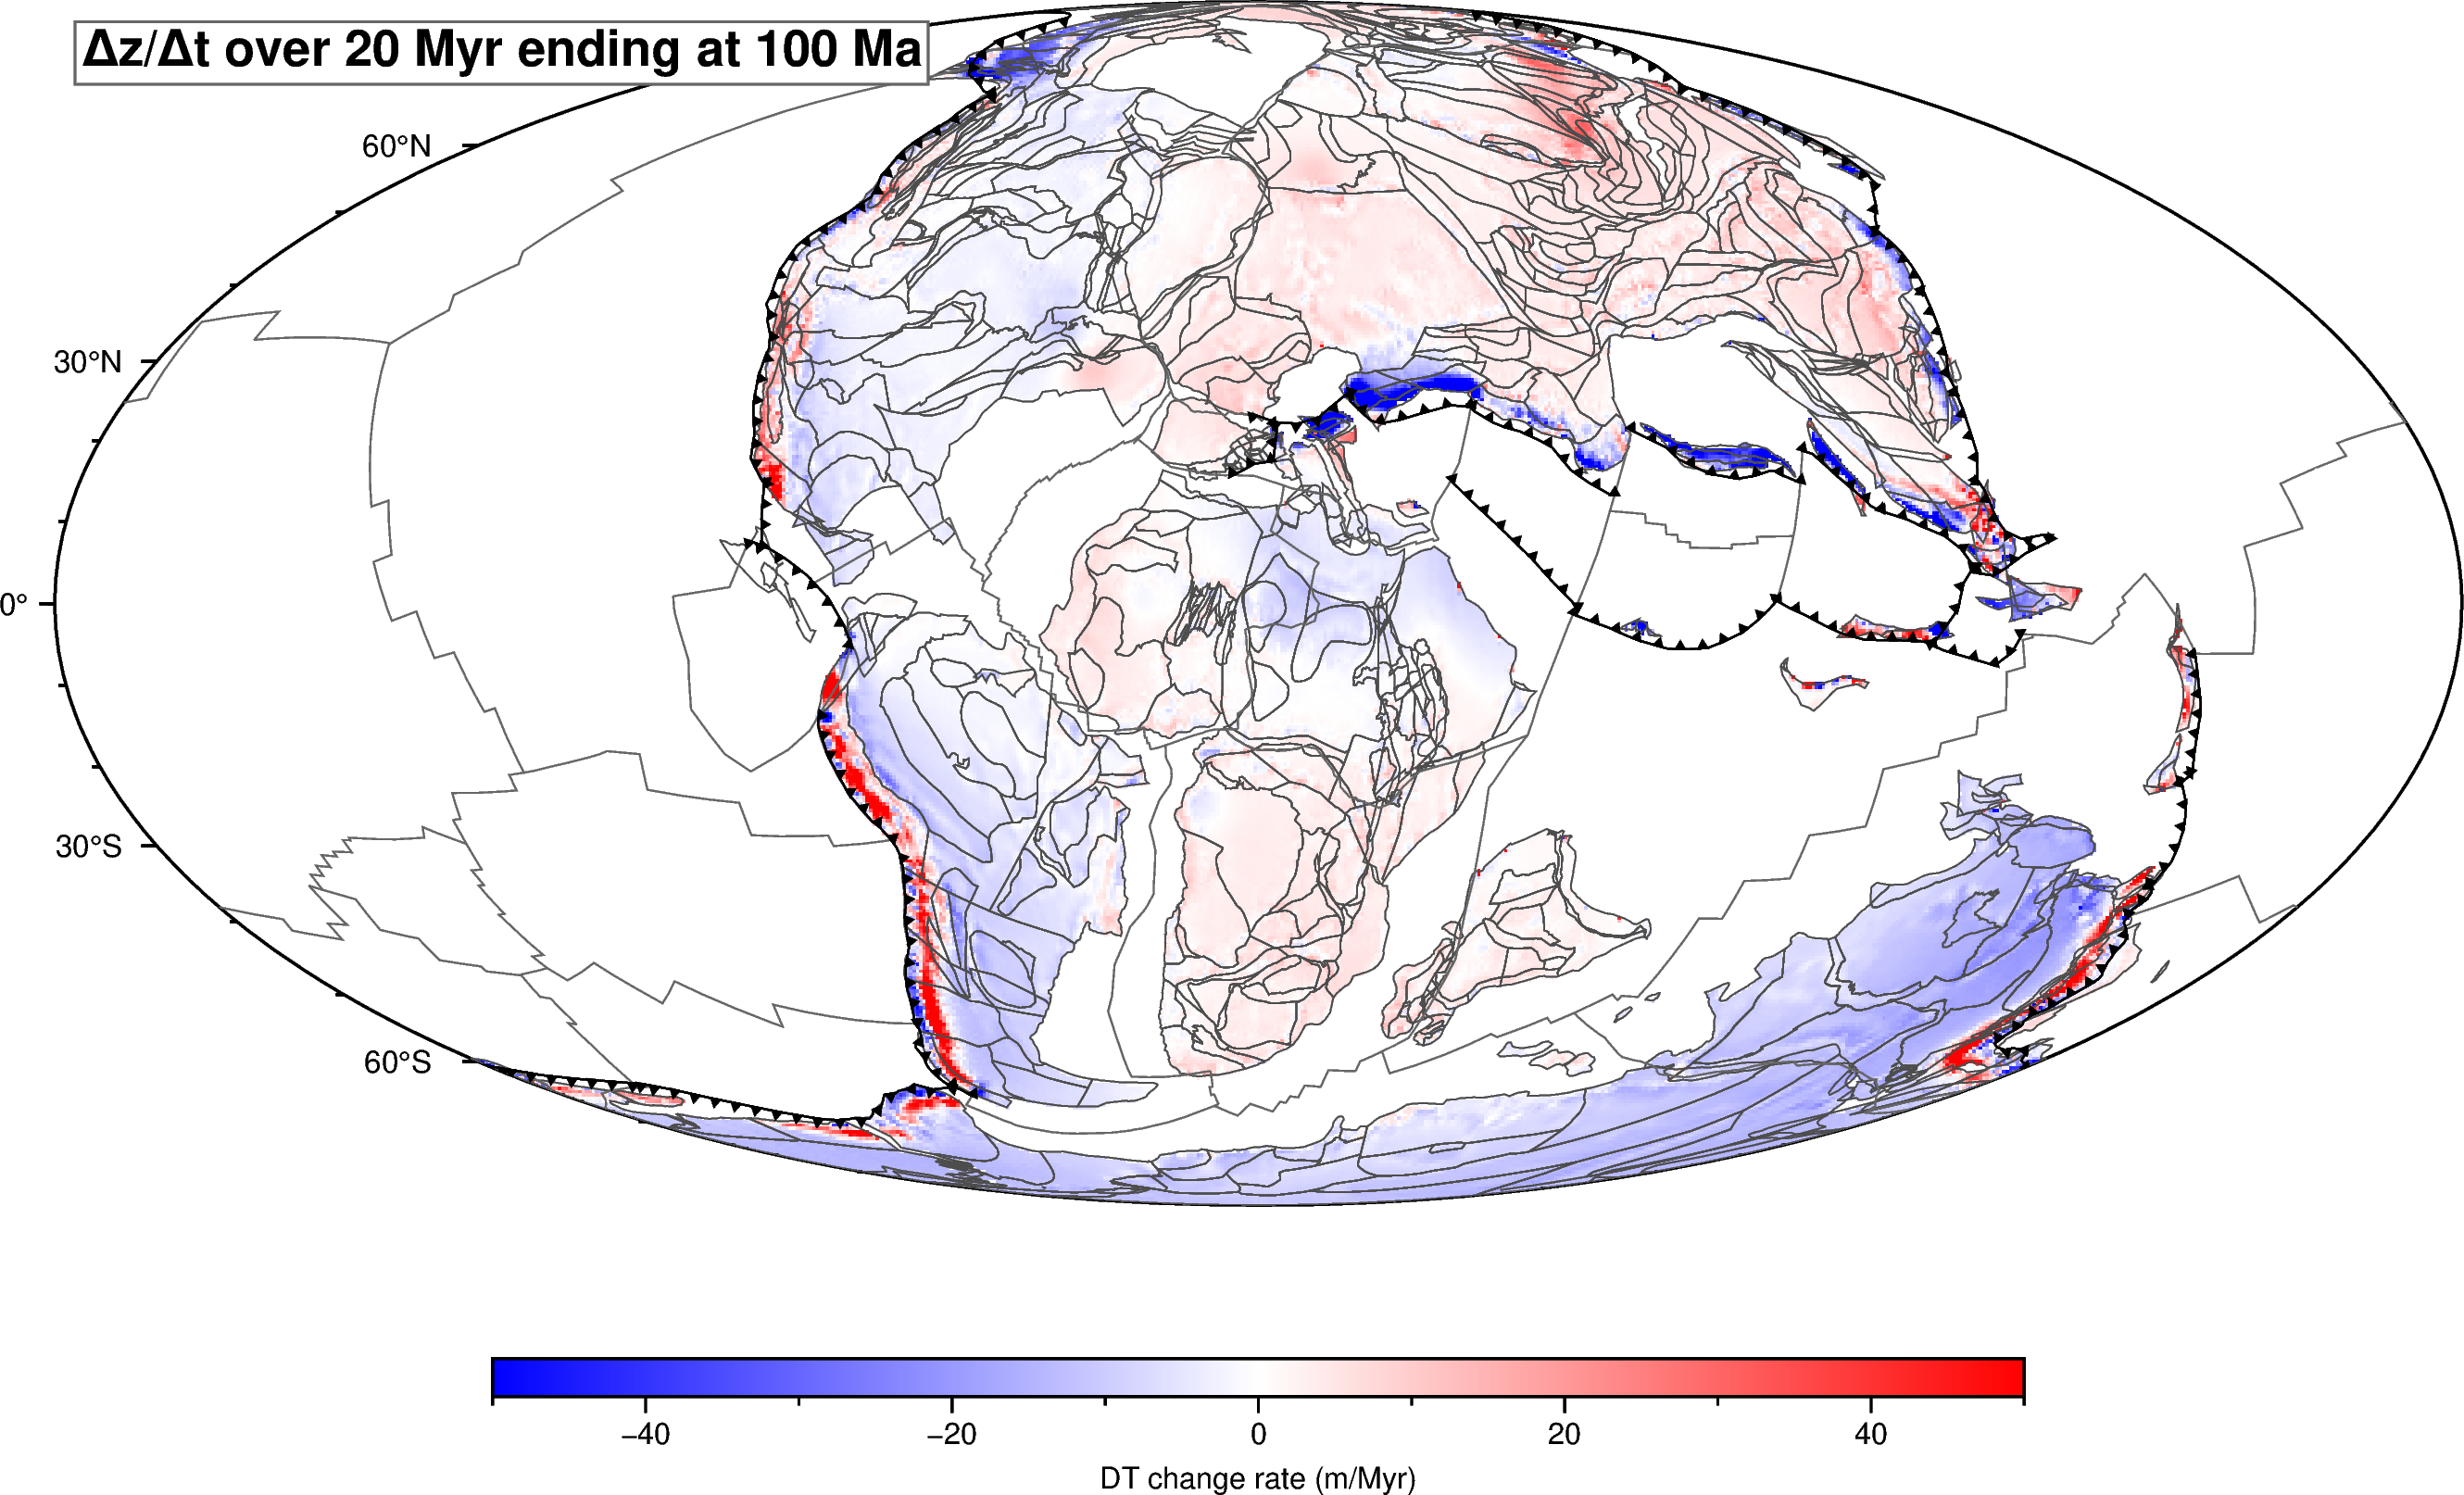

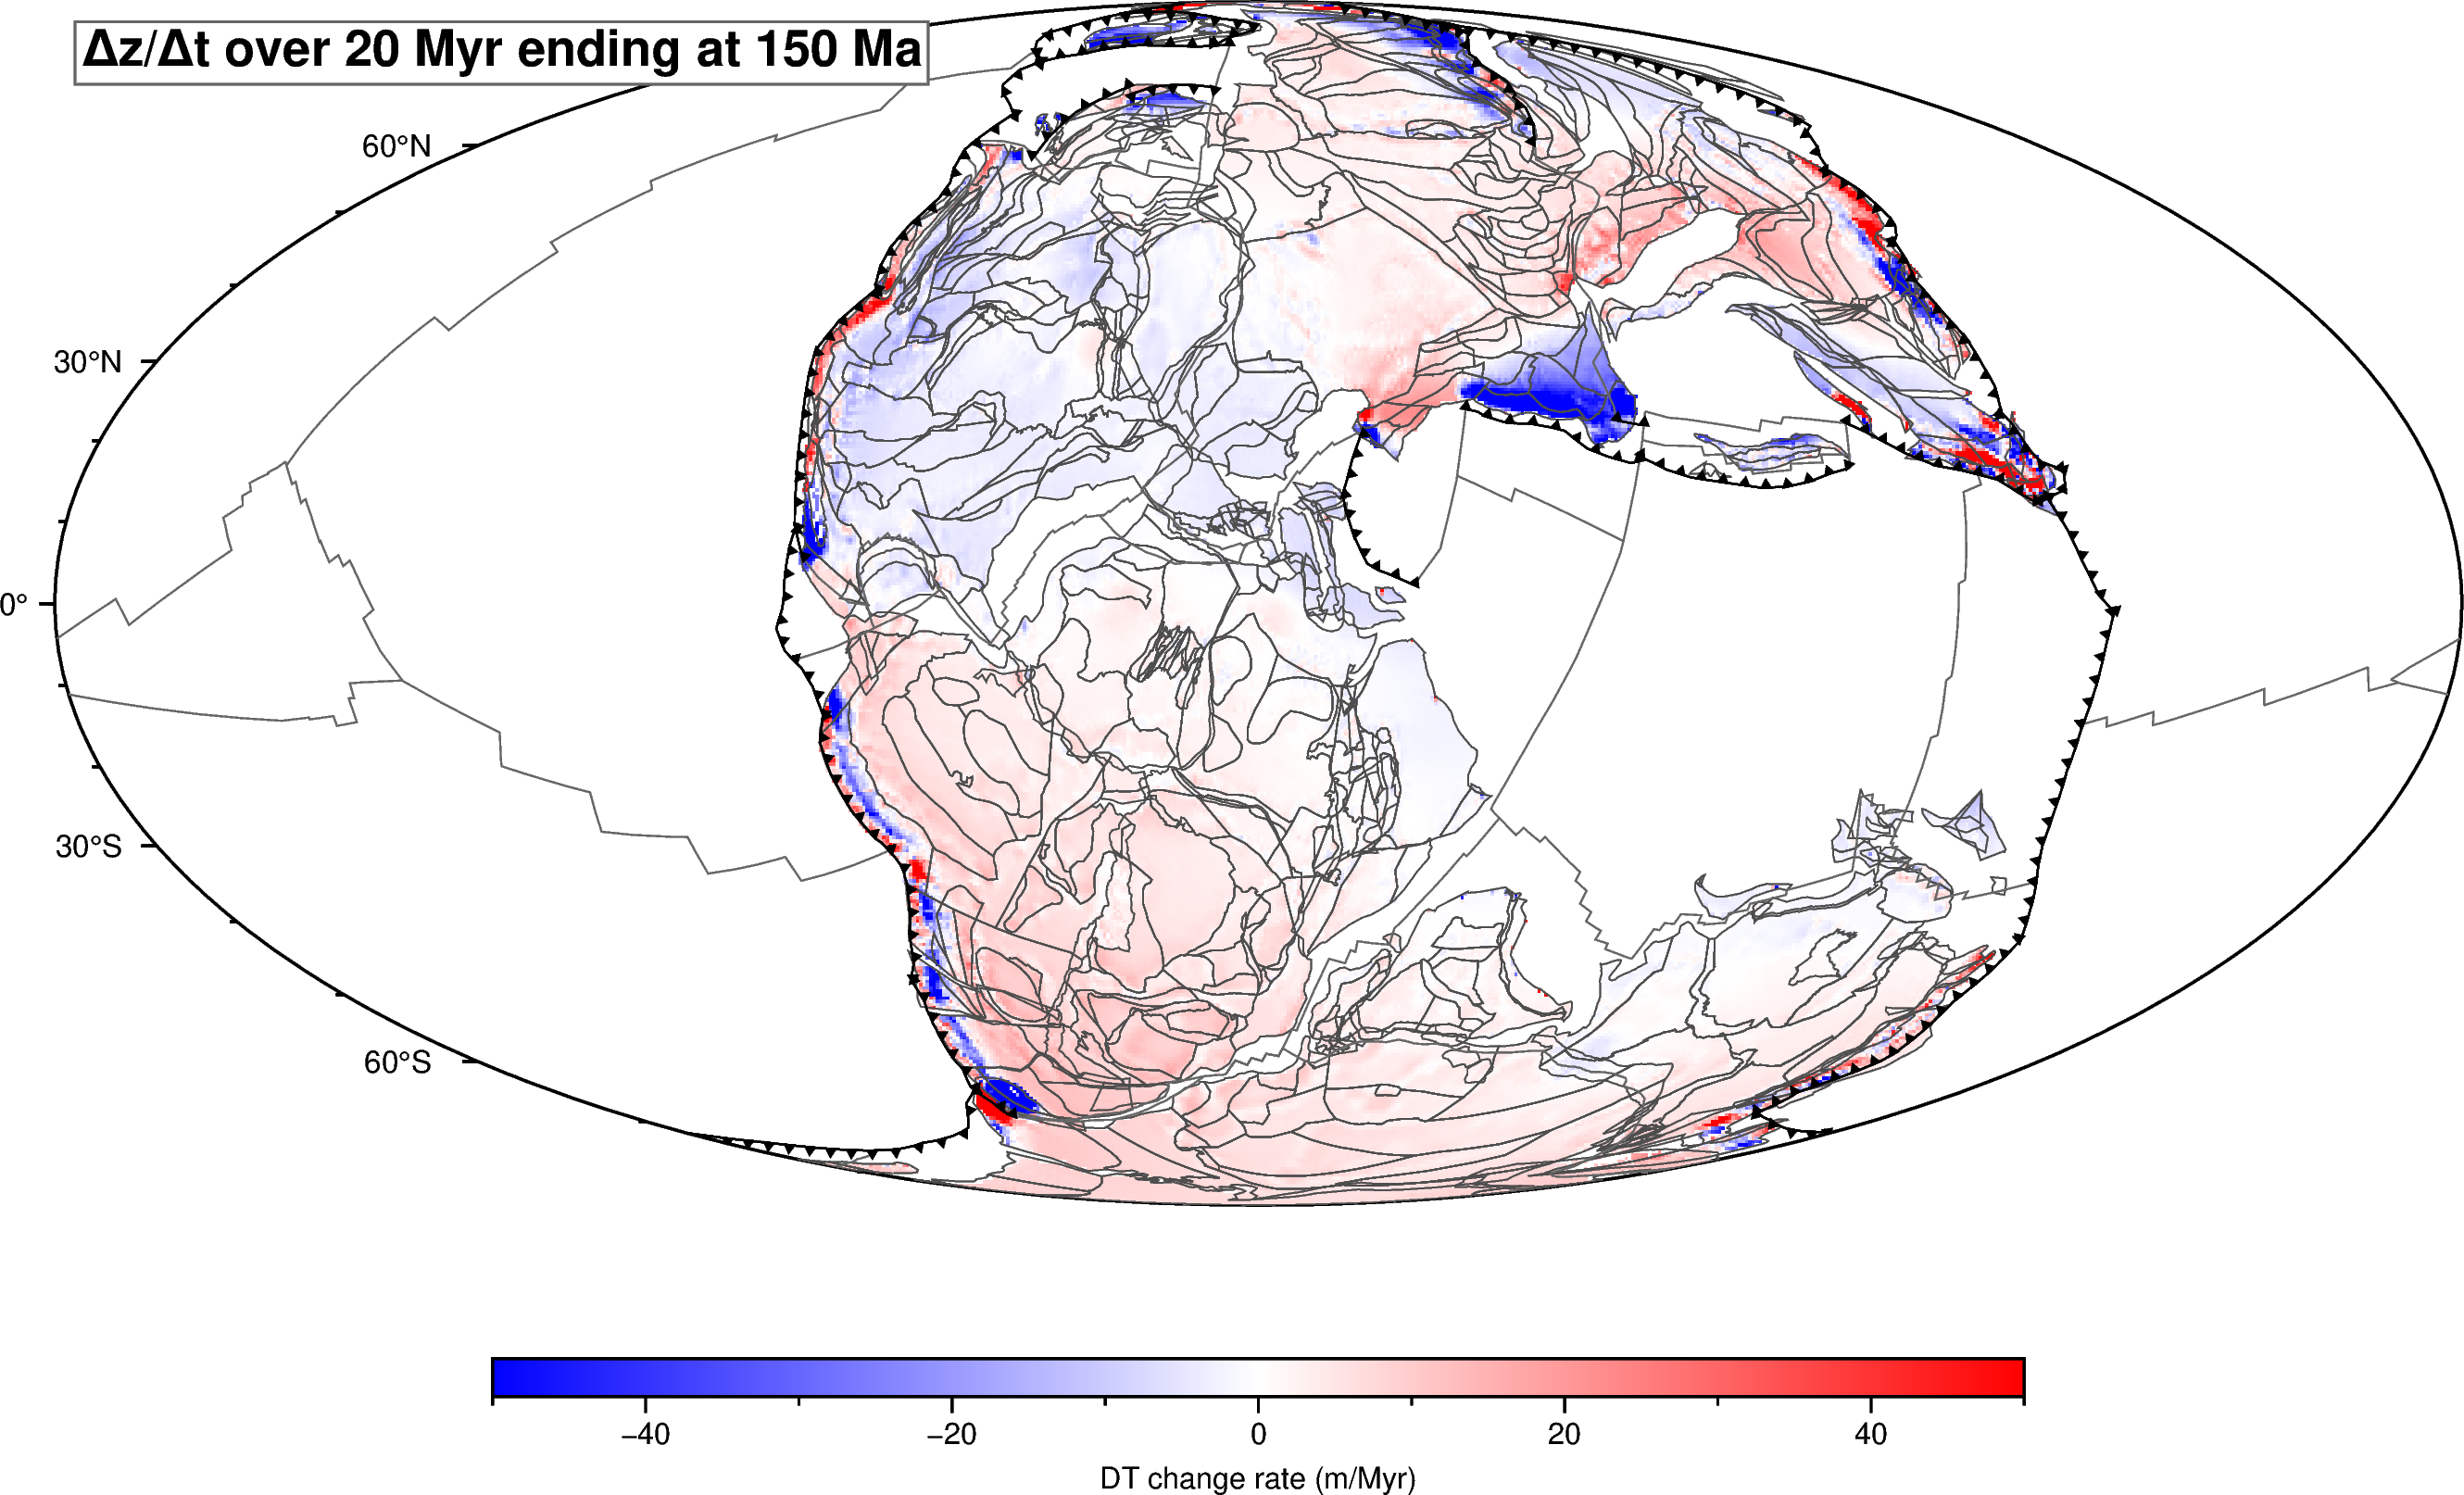

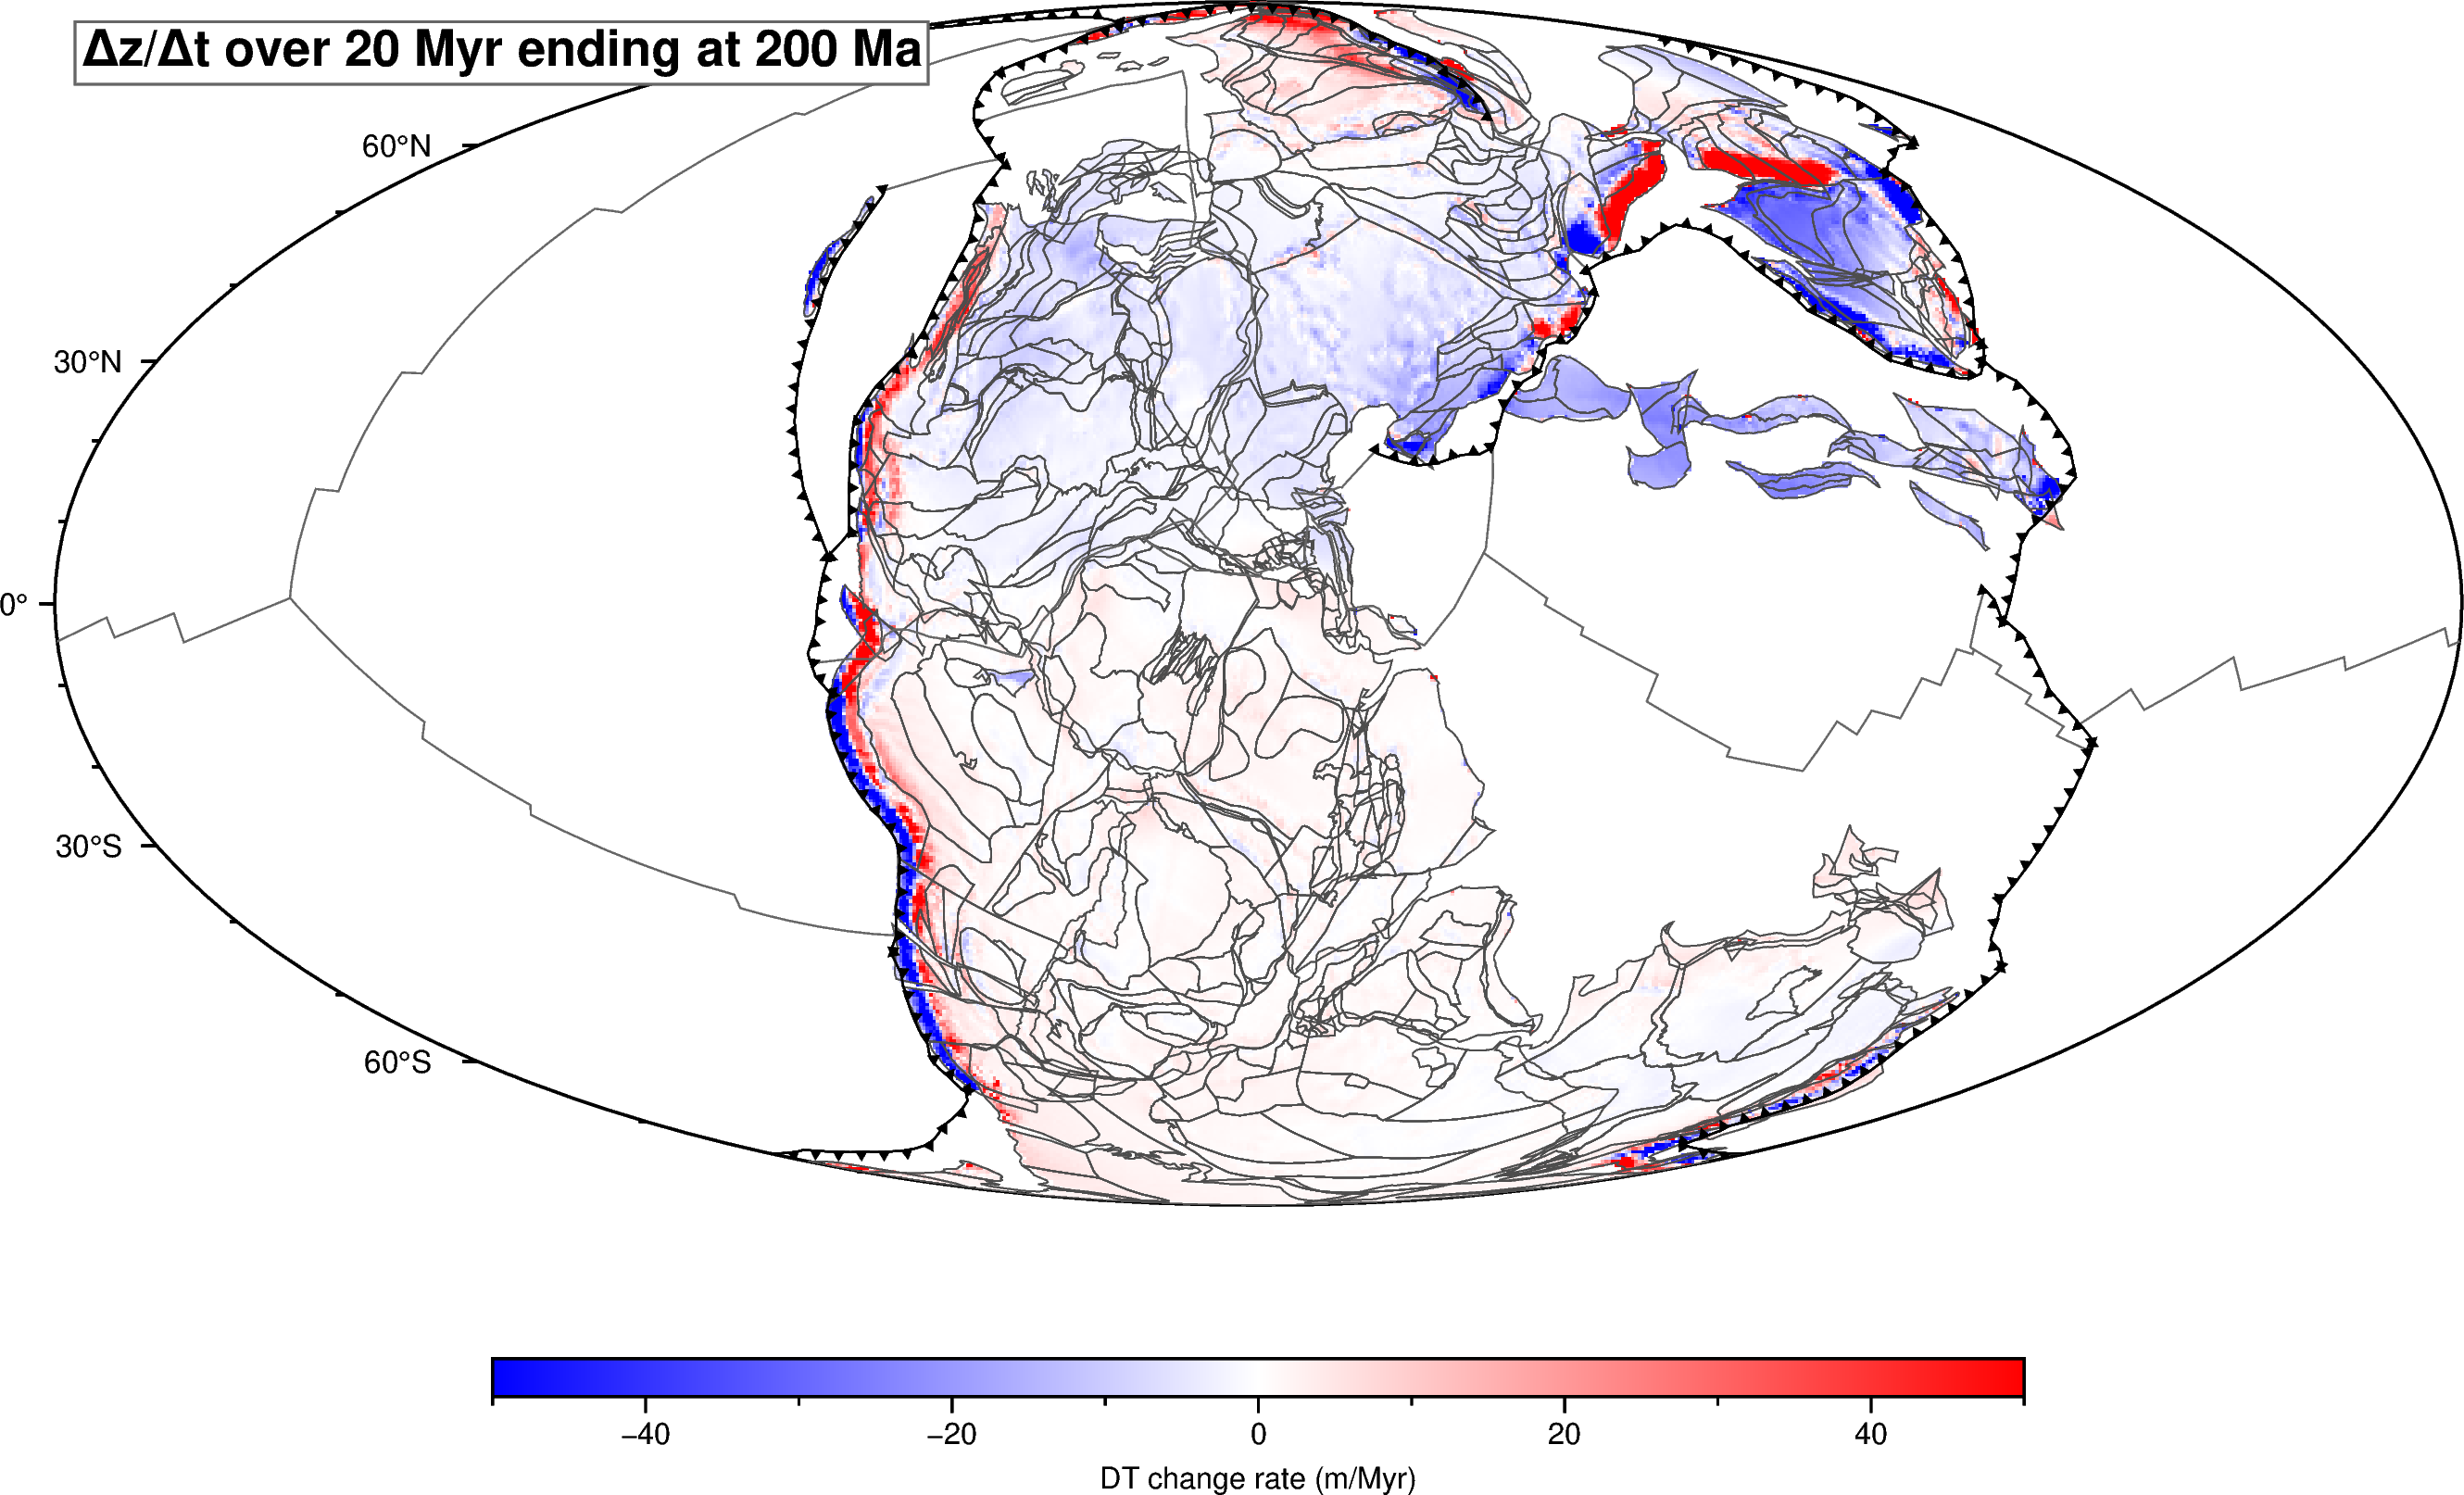

In [7]:
SNAPSHOTS = [50, 100, 150, 200]
for _a in SNAPSHOTS:
    if (_a in age_map) and ((_a + STEP_MYR_5) in age_map):
        _dz = to_paleo(plate_frame_dz(_a, STEP_MYR_5), _a) / float(STEP_MYR_5)
        map_grid(_dz, f'Δz/Δt over {STEP_MYR_5} Myr ending at {_a} Ma',
                 series=(-50, 50, 2), overlay_age=_a, label='DT change rate (m/Myr)')
    else:
        print(f'skip {_a} Ma — need grids at {_a} and {_a+STEP_MYR_5}')


## 7. Extend it — the 20-Myr set (0–960 Ma)

The same code works on the deep-time **20-Myr** grids; only the cadence changes. Set the step to 20 Myr and march through `set20`. This carries the analysis from the Cenozoic all the way into the Neoproterozoic (Rodinia) — useful for pairing DT change with the collisional/supermountain history.

**Try:** uncomment below. (Deep-time DT amplitudes and plate speeds are both larger, so the per-crustal-column Δz signal from §5 grows and the deep-time snapshots in §6 become progressively more informative — a good thing to inspect.)


In [8]:
# STEP_MYR_20 = 20
# for _a in [200, 400, 600, 800]:
#     if (_a in age_map) and ((_a + STEP_MYR_20) in age_map):
#         _dz = to_paleo(plate_frame_dz(_a, STEP_MYR_20), _a) / float(STEP_MYR_20)
#         map_grid(_dz, f'Δz/Δt over {STEP_MYR_20} Myr ending at {_a} Ma (deep-time 20-Myr set)',
#                  series=(-50, 50, 2), overlay_age=_a, label='DT change rate (m/Myr)')


## Summary

- **Mantle frame → plate frame** (`to_plate_frame`) is the load-bearing step: it reverse-rotates each plate from its position at time *t* to present-day, so a crustal column is comparable across ages.
- **Δz** = plate-frame(t) − plate-frame(t+Δ) is the DT change that crust experienced; differencing in the **mantle frame** instead would inject a plate-motion advection artefact.
- Display rotates Δz back onto the paleogeography at *t*.
- Works identically on the **5-Myr (0–250 Ma)** and **20-Myr (0–960 Ma)** Young 2022 sets — just change the step.

## References

- **Young, A., Flament, N., Williams, S.E., Merdith, A., Cao, X. & Müller, R.D. (2022).** Long-term Phanerozoic sea level change from solid Earth processes. *Earth and Planetary Science Letters*, **584**, 117451. https://doi.org/10.1016/j.epsl.2022.117451  
  *(source of the `gld428` dynamic topography grids used here).*

- **Müller, R.D., Flament, N., Cannon, J., Tetley, M.G., Williams, S.E., Cao, X., Bodur, Ö.F., Zahirovic, S. & Merdith, A. (2022).** A tectonic-rules-based mantle reference frame since 1 billion years ago – implications for supercontinent cycles and plate–mantle system evolution. *Solid Earth*, **13**, 1127–1159. https://doi.org/10.5194/se-13-1127-2022  
  *(the M21 NNR no-net-rotation mantle reference frame).*

- **Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., Young, A., Armistead, S.E., Cannon, J., Zahirovic, S. & Müller, R.D. (2021).** Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews*, **214**, 103477. https://doi.org/10.1016/j.earscirev.2020.103477  
  *(the underlying M2021 plate reconstruction).*
